In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("altruistdelhite04/gold-price-data")

print("Path to dataset files:", path)

100%|██████████| 41.9k/41.9k [00:00<00:00, 409kB/s]

Extracting files...
Path to dataset files: C:\Users\manas\.cache\kagglehub\datasets\altruistdelhite04\gold-price-data\versions\1


In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")


In [6]:
df = pd.read_csv("gld_price_data.csv")
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     2290 non-null   datetime64[ns]
 1   SPX      2290 non-null   float64       
 2   GLD      2290 non-null   float64       
 3   USO      2290 non-null   float64       
 4   SLV      2290 non-null   float64       
 5   EUR/USD  2290 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 107.5 KB


In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [11]:
df.isna().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [13]:
# getting the statistical measures of the data
df.describe()

,Date,SPX,GLD,USO,SLV,EUR/USD
count,2290,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,2013-03-17 08:23:41.135371008,1654.315776,122.732875,31.842221,20.084997,1.283653
min,2008-01-02 00:00:00,676.530029,70.000000,7.960000,8.850000,1.039047
25%,2010-08-20 00:00:00,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,2013-03-13 12:00:00,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2015-10-25 00:00:00,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2018-05-16 00:00:00,2872.870117,184.589996,117.480003,47.259998,1.598798
std,NaN,519.111540,23.283346,19.523517,7.092566,0.131547


<Axes: >

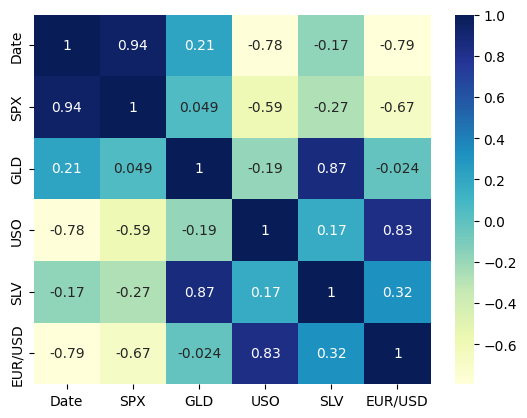

In [14]:
correlation = df.corr()

sns.heatmap(correlation , annot = True , cmap = "YlGnBu")


<Axes: xlabel='GLD', ylabel='Density'>

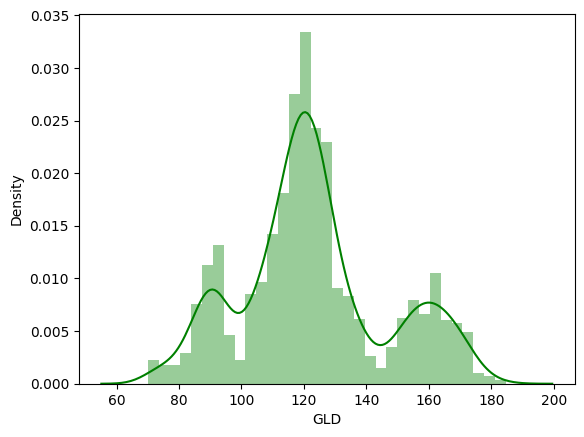

In [15]:
# checking the distribution of the GLD Price
sns.distplot(df['GLD'],color='green')

In [16]:
X = df.drop(['Date','GLD'],axis=1)
y = df['GLD']

from sklearn.model_selection import train_test_split 


In [18]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state  =42)

X_train.shape , y_test.shape

((1832, 4), (458,))

In [20]:
from sklearn.ensemble import RandomForestRegressor 

model = RandomForestRegressor(n_estimators= 100 , criterion='squared_error', max_depth=10, random_state=0)

model.fit(X_train , y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error , r2_score

print("Mean Squared Error : " , mean_squared_error(y_test , y_pred))
print("R2 Score : " , r2_score(y_test , y_pred))



Mean Squared Error :  6.04094301278521
R2 Score :  0.9889824107928189


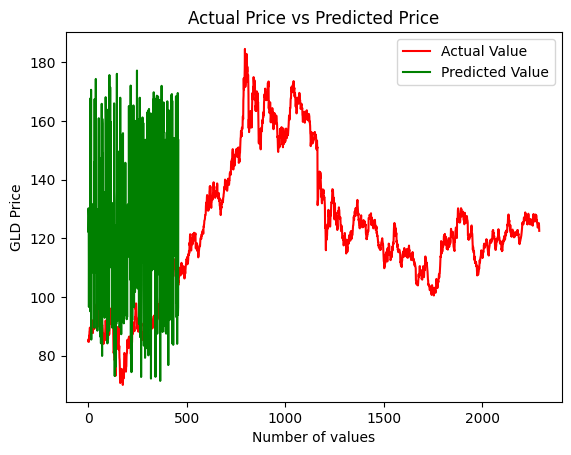

In [21]:
plt.plot(y, color='red', label='Actual Value')
plt.plot(y_pred, color='green', label='Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()